### **Credit_Card Customer_Segmentation By GMM**
---

In [301]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


In [302]:
df=pd.read_csv('credit_card_customer_data.csv')

#### **Daat Understanding**
---

In [303]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [304]:
df.shape

(660, 7)

In [305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [306]:
df.dtypes

Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object

In [307]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [308]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
df.nunique()

#5 Customer Keys repeated with different attributes, kept

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

#### **EDA & Data Preprocessing**
---

In [311]:
df = df.drop(columns=['Sl_No', 'Customer Key']).reset_index(drop=True)
features = df.columns.tolist()

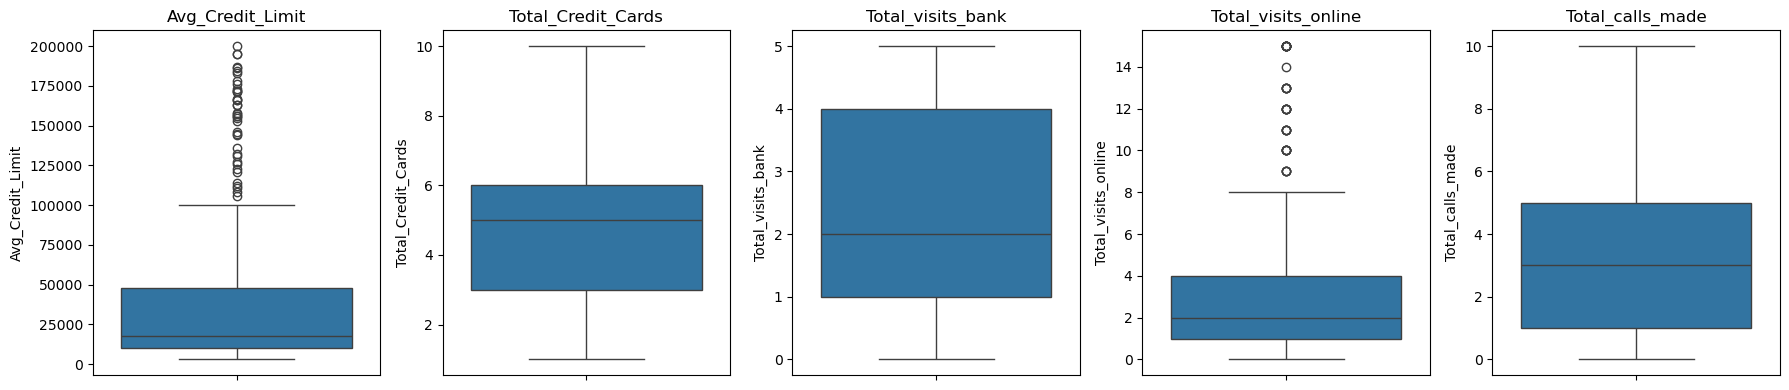

In [312]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for a, c in zip(axes, features):
    sns.boxplot(y=df[c], ax=a)
    a.set_title(c)
plt.tight_layout()
plt.show()

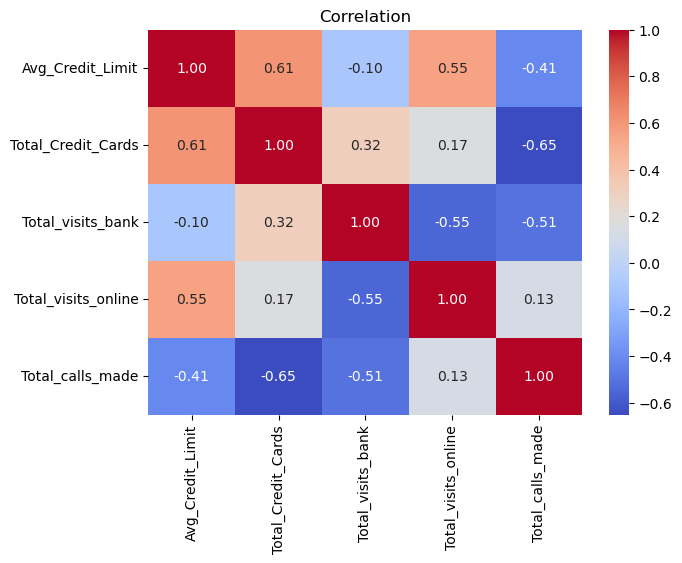

In [313]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation')
plt.show()

In [314]:
X = df.copy()
X['Avg_Credit_Limit'] = np.log1p(X['Avg_Credit_Limit'])

In [315]:
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=features)
X_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.630500,-1.249225,-0.860451,-0.547490,-1.251537
1,0.885383,-0.787585,-1.473731,2.520519,1.891859
2,0.885383,1.058973,-0.860451,0.134290,0.145528
3,0.336263,0.135694,-0.860451,-0.547490,0.145528
4,1.630500,0.597334,-1.473731,3.202298,-0.203739


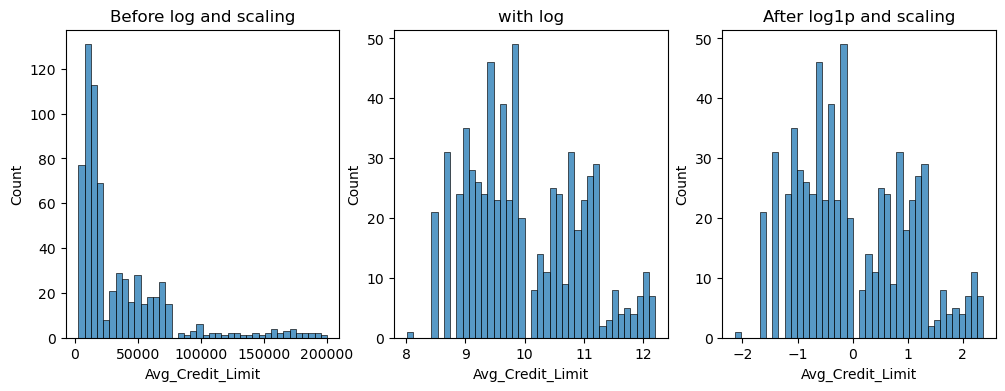

In [316]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(df['Avg_Credit_Limit'], bins=40, ax=ax[0])
sns.histplot(X['Avg_Credit_Limit'], bins=40, ax=ax[1])
sns.histplot(X_scaled['Avg_Credit_Limit'], bins=40, ax=ax[2])

ax[0].set_title('Before log and scaling'); 
ax[1].set_title('with log'); 
ax[2].set_title('After log1p and scaling')
plt.show()

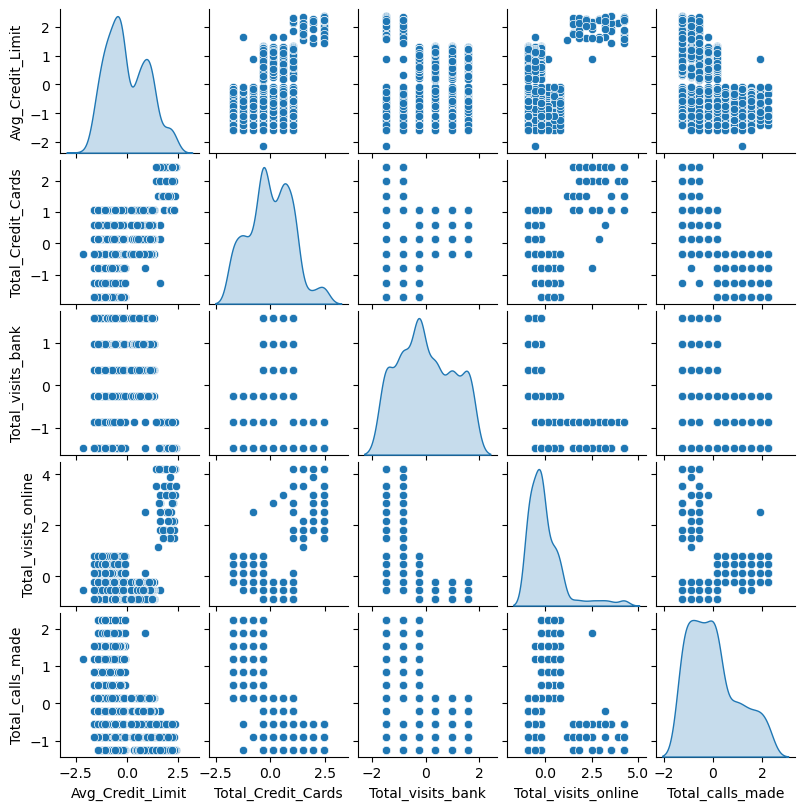

In [317]:
g = sns.pairplot(X_scaled, diag_kind="kde")
g.figure.set_size_inches(8, 8)

#### **GMM**
---

In [318]:
kr = range(2, 9)
cov_types = ['full', 'tied', 'diag', 'spherical']
results = []

for cov in cov_types:
    for k in kr:
        g = GaussianMixture(n_components=k, covariance_type=cov, n_init=10, random_state=42, reg_covar=0.05)
        labels = g.fit_predict(X_scaled)
        results.append({'cov': cov, 'k': k,
                'BIC': g.bic(X_scaled), 'AIC': g.aic(X_scaled),
                'Silhouette': silhouette_score(X_scaled, labels)})

res = pd.DataFrame(results)
print(res.sort_values('BIC').head(10).round(2))

          cov  k      BIC      AIC  Silhouette
16       diag  4  6434.18  6241.01        0.38
17       diag  5  6463.10  6220.52        0.34
15       diag  3  6473.89  6330.14        0.49
18       diag  6  6519.45  6227.46        0.27
19       diag  7  6568.39  6226.98        0.33
13       tied  8  6577.52  6299.01        0.24
12       tied  7  6613.18  6361.62        0.24
11       tied  6  6621.52  6396.91        0.33
27  spherical  8  6623.23  6376.15        0.25
20       diag  8  6629.41  6238.59        0.25


In [ ]:
# **Note on BIC.** With the default `reg_covar=1e-6`, BIC kept decreasing for large K
# (lowest at K=8 with `diag`: 3659), while Silhouette dropped to 0.12. The minimum fitted
# variance was ≈1e-6, i.e. a component collapsed onto a single discrete value of an
# integer-valued feature (visits, calls, cards), which inflates the likelihood without
# reflecting a real segment. Refitting K=8 with `reg_covar=0.05` raised BIC to 6629,
# above K=3 (6390) and K=4 (6328), which removes the conflict with Silhouette.
# K=3 was selected based on Silhouette, Davies-Bouldin, and the interpretability of
# the cluster profiles.

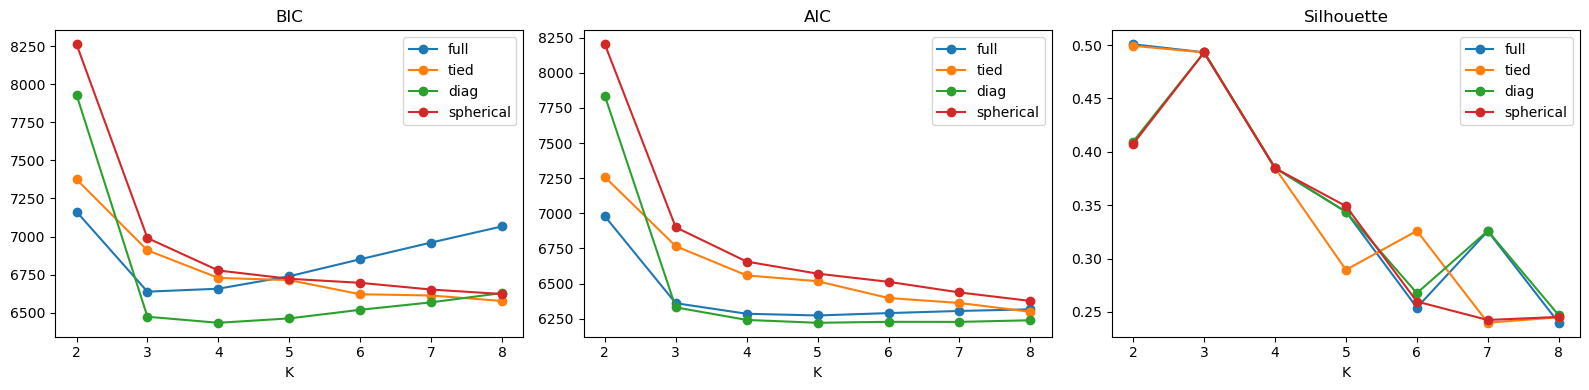

In [319]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for cov in cov_types:
    d = res[res['cov'] == cov]
    ax[0].plot(d['k'], d['BIC'], 'o-', label=cov)
    ax[1].plot(d['k'], d['AIC'], 'o-', label=cov)
    ax[2].plot(d['k'], d['Silhouette'], 'o-', label=cov)

for a, t in zip(ax, ['BIC', 'AIC', 'Silhouette']):
    a.set_title(t)
    a.set_xlabel('K')
    a.legend()
    
plt.tight_layout()
plt.show()

In [320]:
for k in [3, 4]:
    g = GaussianMixture(n_components=k, covariance_type='diag', n_init=20, random_state=42, reg_covar=0.05).fit(X_scaled)
    df[f'GMM{k}'] = g.predict(X_scaled)
    print(f"\n=== K={k} ===")
    print(df[f'GMM{k}'].value_counts().sort_index())
    print(df.groupby(f'GMM{k}')[features].mean().round(1))


=== K=3 ===
GMM3
0    387
1     50
2    223
Name: count, dtype: int64
      Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
GMM3                                                            
0              33733.9                 5.5                3.5   
1             141040.0                 8.7                0.6   
2              12161.4                 2.4                0.9   

      Total_visits_online  Total_calls_made  
GMM3                                         
0                     1.0               2.0  
1                    10.9               1.1  
2                     3.6               6.9  

=== K=4 ===
GMM4
0    168
1     50
2    223
3    219
Name: count, dtype: int64
      Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
GMM4                                                            
0              12238.1                 5.5                3.6   
1             141040.0                 8.7                0.6   
2              12197.3           

In [321]:
print(pd.crosstab(df['GMM3'], df['GMM4']))

GMM4    0   1    2    3
GMM3                   
0     167   0    1  219
1       0  50    0    0
2       1   0  222    0


In [322]:
# ---------- 1) Final GMM ----------
gmm = GaussianMixture(n_components=3, covariance_type='diag', n_init=20, random_state=42, reg_covar=0.05).fit(X_scaled)

df['Cluster'] = gmm.predict(X_scaled)
proba = gmm.predict_proba(X_scaled)
df['Confidence'] = proba.max(axis=1)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# ---------- 2) Evaluation ----------
labels = df['Cluster']
print("Converged:", gmm.converged_)
print("Silhouette:", round(silhouette_score(X_scaled, labels), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, labels), 3))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, labels), 1))

# All three metrics measure two things: 
# are customers inside the same cluster close to each other,
# and are the clusters themselves far from one another?

Converged: True
Silhouette: 0.493
Davies-Bouldin: 0.728
Calinski-Harabasz: 664.9


In [324]:
# ---------- 3) Soft assignment ----------
print((df['Confidence'] < 0.9).sum())
print(df.groupby('Cluster')['Confidence'].describe().round(3))

5
         count   mean    std    min  25%  50%  75%  max
Cluster                                                
0        387.0  0.998  0.025  0.546  1.0  1.0  1.0  1.0
1         50.0  1.000  0.000  1.000  1.0  1.0  1.0  1.0
2        223.0  0.995  0.037  0.523  1.0  1.0  1.0  1.0


In [325]:
# ---------- 4) Profiling ----------
print(df['Cluster'].value_counts().sort_index())

Cluster
0    387
1     50
2    223
Name: count, dtype: int64


In [326]:
print(df.groupby('Cluster')[features].mean().round(1))

         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0                 33733.9                 5.5                3.5   
1                141040.0                 8.7                0.6   
2                 12161.4                 2.4                0.9   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                        1.0               2.0  
1                       10.9               1.1  
2                        3.6               6.9  


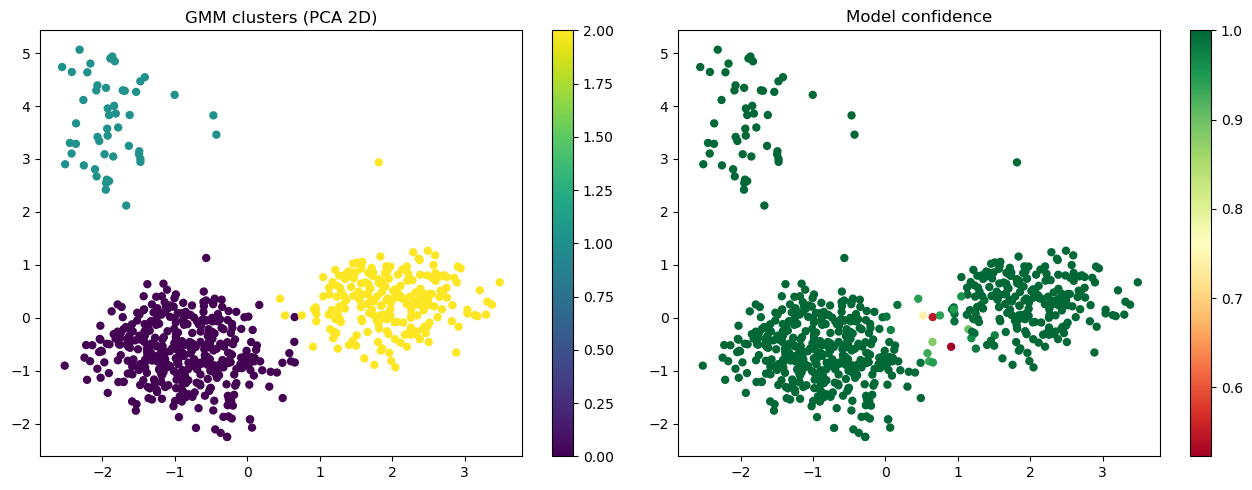

In [327]:
# ---------- 5) Visualization ----------
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sc = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=25)
ax[0].set_title('GMM clusters (PCA 2D)')
plt.colorbar(sc, ax=ax[0])

sc = ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Confidence'], cmap='RdYlGn', s=25)
ax[1].set_title('Model confidence')
plt.colorbar(sc, ax=ax[1])

plt.tight_layout()
plt.show()

In [ ]:
means = df.groupby('Cluster')[features].mean()

names = {}
names[means['Avg_Credit_Limit'].idxmax()] = 'High-Limit Online'
names[means['Total_calls_made'].idxmax()]  = 'Phone-Reliant'
names[means['Total_visits_bank'].idxmax()] = 'Branch-Oriented'

print(names) 

{np.int64(1): 'High-Limit Online', np.int64(2): 'Phone-Reliant', np.int64(0): 'Branch-Oriented'}


In [329]:
df['Segment'] = df['Cluster'].map(names)
print(df['Segment'].value_counts())

Segment
Branch-Oriented      387
Phone-Reliant        223
High-Limit Online     50
Name: count, dtype: int64


In [330]:
print(df.groupby('Segment')[features].mean().round(1))

                   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Segment                                                                      
Branch-Oriented             33733.9                 5.5                3.5   
High-Limit Online          141040.0                 8.7                0.6   
Phone-Reliant               12161.4                 2.4                0.9   

                   Total_visits_online  Total_calls_made  
Segment                                                   
Branch-Oriented                    1.0               2.0  
High-Limit Online                 10.9               1.1  
Phone-Reliant                      3.6               6.9  
